# Lab 8: FFT & Spectrogram Analysis of Tone-Evoked LFPs

#### Stephen Spivack, CDS Adjunct, Fall 2025

In this lab, we will explore the following signal processing tools applied to local field potentials (LFPs) evoked by auditory tones:

1. Fast Fourier Transform (FFT): Used to compute the frequency spectrum of time-domain signals by decomposing them into sine wave components.
2. Spectrograms: Time–frequency representations that show how the signal's frequency content evolves over time.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
from scipy.signal import chirp, spectrogram, windows
from scipy.fft import fft, fftfreq
import sounddevice as sd

/Users/sspivack/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
%load_ext google.cloud.bigquery
client = bigquery.Client() 

In [3]:
%%bigquery auditory_cortex
    select
      session,
      condition,
      frequency,
      amplitude,
      trial_num,
      array(select safe_cast(x as float64) from unnest(split(trace, ',')) as x) as trace
    from neural-ds-fe73.lab6_mouse_lfp.auditory_cortex

Query is running:   0%|          |

Downloading:   0%|          |

In [4]:
auditory_cortex

,session,condition,frequency,amplitude,trial_num,trace
0,3,WT,16035,30,14,"[-1.4476278100552333, -1.3878077077536775, -1...."
1,3,WT,16035,30,37,"[0.12918264234022386, 0.09510574514985676, 0.0..."
2,18,FMR1,11332,50,18,"[4.225877015767566, 4.2205647023067865, 4.2125..."
3,18,FMR1,11332,50,30,"[0.4503535540060088, 0.4286574386567467, 0.407..."
4,18,FMR1,11332,50,42,"[-3.354921901112686, -3.3049606991055334, -3.2..."
...,...,...,...,...,...,...
77413,42,WT,32000,30,9,"[3.4197943890668068, 3.3375951097221916, 3.261..."
77414,42,WT,32000,30,10,"[-13.497923078599658, -13.449870741900348, -13..."
77415,42,WT,32000,30,15,"[0.7102204528756748, 0.6124648042769105, 0.514..."
77416,42,WT,32000,30,28,"[-0.9644656345307031, -0.9661364869565489, -0...."


## Fast Fourier Transform (FFT)

To analyze the **frequency content** of an LFP trace, we apply the **Discrete Fourier Transform (DFT)** using the Fast Fourier Transform (FFT) algorithm. This decomposes the signal into a sum of complex sinusoids:

$$
\hat{V}(f_k) = \sum_{n=0}^{N-1} V(t_n) \cdot e^{-2\pi i f_k t_n}
$$

**Where:**
- $V(t_n)$: voltage at time $t_n$  
- $\hat{V}(f_k)$: complex amplitude at frequency $f_k$  
- $f_k = \frac{k}{N \Delta t}$: frequency bin (up to Nyquist)  
- $N$: number of samples  
- $\Delta t$: sampling interval (e.g., 1 ms at 1000 Hz)  

---

### Interpreting the FFT Output

- `np.fft.fft` returns **complex values**: use `np.abs(...)` to get magnitude  
- Only the **first half** of the FFT corresponds to unique (positive) frequencies  
- The **Nyquist frequency** is the highest meaningful frequency:  
  $f_{\text{Nyquist}} = \frac{1}{2\Delta t}$

---

### Implementation
```python
from scipy.fft import fft, fftfreq

N = len(trace)
dt = 1 / fs  # Sampling interval
freqs = fftfreq(N, d=dt)[:N//2]
spectrum = np.abs(fft(trace)[:N//2])


## Spectrogram (Short-Time Fourier Transform)

To visualize how frequency content evolves over time, we apply the **Short-Time Fourier Transform (STFT)**. This involves sliding a window $w(t)$ across the signal and computing the FFT within each windowed segment:

$$
S(t, f) = \left| \sum_{\tau = -\infty}^{\infty} V(\tau) \cdot w(\tau - t) \cdot e^{-2\pi i f \tau} \right|^2
$$

**Where:**
- $V(\tau)$: input LFP signal  
- $w(\tau - t)$: window function centered at time $t$ (e.g., Hann window)  
- $S(t, f)$: power at frequency $f$ and time $t$  

---

### Key Tradeoff: Time vs Frequency Resolution

- **Short windows** → better time resolution, worse frequency resolution  
- **Long windows** → better frequency resolution, but blur in time  

We control this tradeoff using the following arguments:

- `nperseg`: length of each segment in samples (i.e. window size)  
- `noverlap`: number of samples to overlap between segments  
- `nfft`: number of FFT points (zero-padded if `nfft > nperseg`, gives smoother frequency bins)  
- `window`: the shape of the window function (e.g., `'hann'`, `'hamming'`, `'blackman'`, etc.)

---

### Implementation
```python
from scipy.signal import spectrogram, windows

nperseg = 256                    # Segment (window) length
noverlap = 255                   # Overlap between segments
nfft = 512                       # Number of FFT points (zero-padded for smoothness)
window = windows.hann(nperseg)   # Window function

f, t_spec, Sxx = spectrogram(
    trace,
    fs=fs,
    window=window,
    noverlap=noverlap,
    nperseg=nperseg,
    nfft=nfft
)


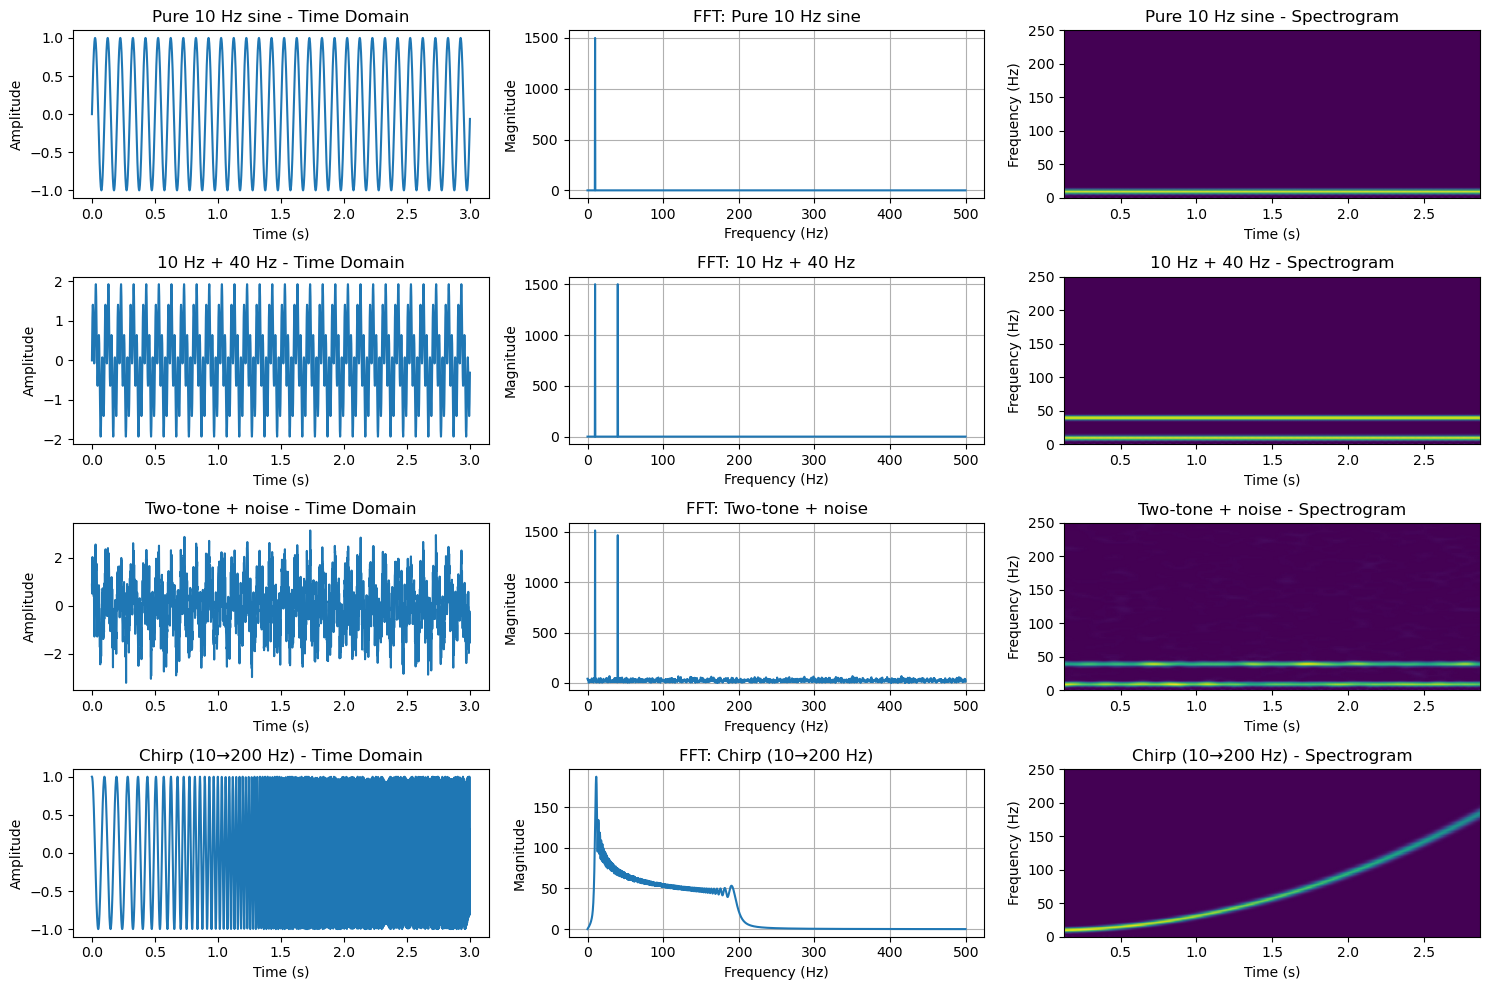

In [6]:
# --- Parameters ---
fs = 1000  # Sampling rate in Hz (1000 samples per second)
dur = 3    # Duration of the signal in seconds
t = np.linspace(0, dur, int(fs * dur), endpoint=False)  # Time vector from 0 to dur with fs * dur samples

# --- 1. Pure sine wave ---
freq1 = 10  # Frequency of the sine wave in Hz
signal1 = np.sin(2 * np.pi * freq1 * t)  # Generate a 10 Hz sine wave

# --- 2. Two-tone signal ---
freq2 = 40  # Second frequency in Hz
signal2 = np.sin(2 * np.pi * freq1 * t) + np.sin(2 * np.pi * freq2 * t)  # Superimpose 10 Hz and 40 Hz sine waves

# --- 3. Noisy signal ---
np.random.seed(0)  # Seed the random number generator for reproducibility
noise = np.random.normal(0, 0.5, size=t.shape)  # Generate Gaussian noise with mean 0 and std 0.5
signal3 = signal2 + noise  # Add noise to the two-tone signal

# --- 4. Chirp signal (10→200 Hz over 3s) ---
chirp_signal = chirp(t, f0=10, f1=200, t1=dur, method='quadratic')  # Generate a quadratic chirp from 10 Hz to 200 Hz

# --- FFT helper ---
def plot_fft(signal, title, fs=1000):
    N = len(signal)  # Number of samples
    Y = np.fft.fft(signal)  # Compute the Fast Fourier Transform (FFT)
    freqs = np.fft.fftfreq(N, d=1/fs)  # Generate frequency bins
    plt.plot(freqs[:N//2], np.abs(Y[:N//2]))  # Plot magnitude spectrum (one-sided); first half (positive freqs)
    plt.title(f"FFT: {title}")  # Set plot title
    plt.xlabel("Frequency (Hz)")  # Label x-axis
    plt.ylabel("Magnitude")  # Label y-axis
    plt.grid(True)  # Add grid

# --- Spectrogram helper ---
def plot_spec(signal, fs=1000, title="Spectrogram"):
    window = windows.hann(256)  # Define Hann window of length 256
    noverlap = 255  # Set overlap between segments
    f, tt, Sxx = spectrogram(signal, fs=fs, window=window, noverlap=noverlap, nperseg=256, nfft=512)  # Compute spectrogram
    plt.pcolormesh(tt, f, Sxx, shading='gouraud')  # Display spectrogram as a heatmap
    plt.ylim([0, 250])  # Limit frequency axis to 250 Hz
    plt.xlabel("Time (s)")  # Label x-axis
    plt.ylabel("Frequency (Hz)")  # Label y-axis
    plt.title(title)  # Set plot title

# --- Plot all signals ---
plt.figure(figsize=(15, 10))  # Create a new figure with custom size

# List of signals and their titles
signals = [
    (signal1, "Pure 10 Hz sine"),
    (signal2, "10 Hz + 40 Hz"),
    (signal3, "Two-tone + noise"),
    (chirp_signal, "Chirp (10→200 Hz)")
]

# Loop through each signal and generate plots
for i, (sig, title) in enumerate(signals, start=1):
    # Time-domain plot
    plt.subplot(4, 3, 3*(i-1) + 1)  # Subplot in 4 rows, 3 columns
    plt.plot(t, sig)  # Plot the raw signal
    plt.title(f"{title} - Time Domain")  # Title for time-domain plot
    plt.xlabel("Time (s)")  # x-axis label
    plt.ylabel("Amplitude")  # y-axis label

    # Frequency-domain (FFT) plot
    plt.subplot(4, 3, 3*(i-1) + 2)  # FFT plot
    plot_fft(sig, title, fs)  # Call FFT plot helper

    # Spectrogram plot
    plt.subplot(4, 3, 3*(i-1) + 3)  # Spectrogram plot
    plot_spec(sig, fs, f"{title} - Spectrogram")  # Call spectrogram helper

plt.tight_layout()  # Optimize layout spacing
plt.show()  # Show all plots

# --- Optional: Audio playback (comment out if not desired) ---
sd.play(signal1, samplerate=fs); sd.wait()  # Play pure sine wave
sd.play(signal2, samplerate=fs); sd.wait()  # Play two-tone signal
sd.play(signal3, samplerate=fs); sd.wait()  # Play noisy signal
sd.play(chirp_signal, samplerate=fs); sd.wait()  # Play chirp signal



--- WT ---


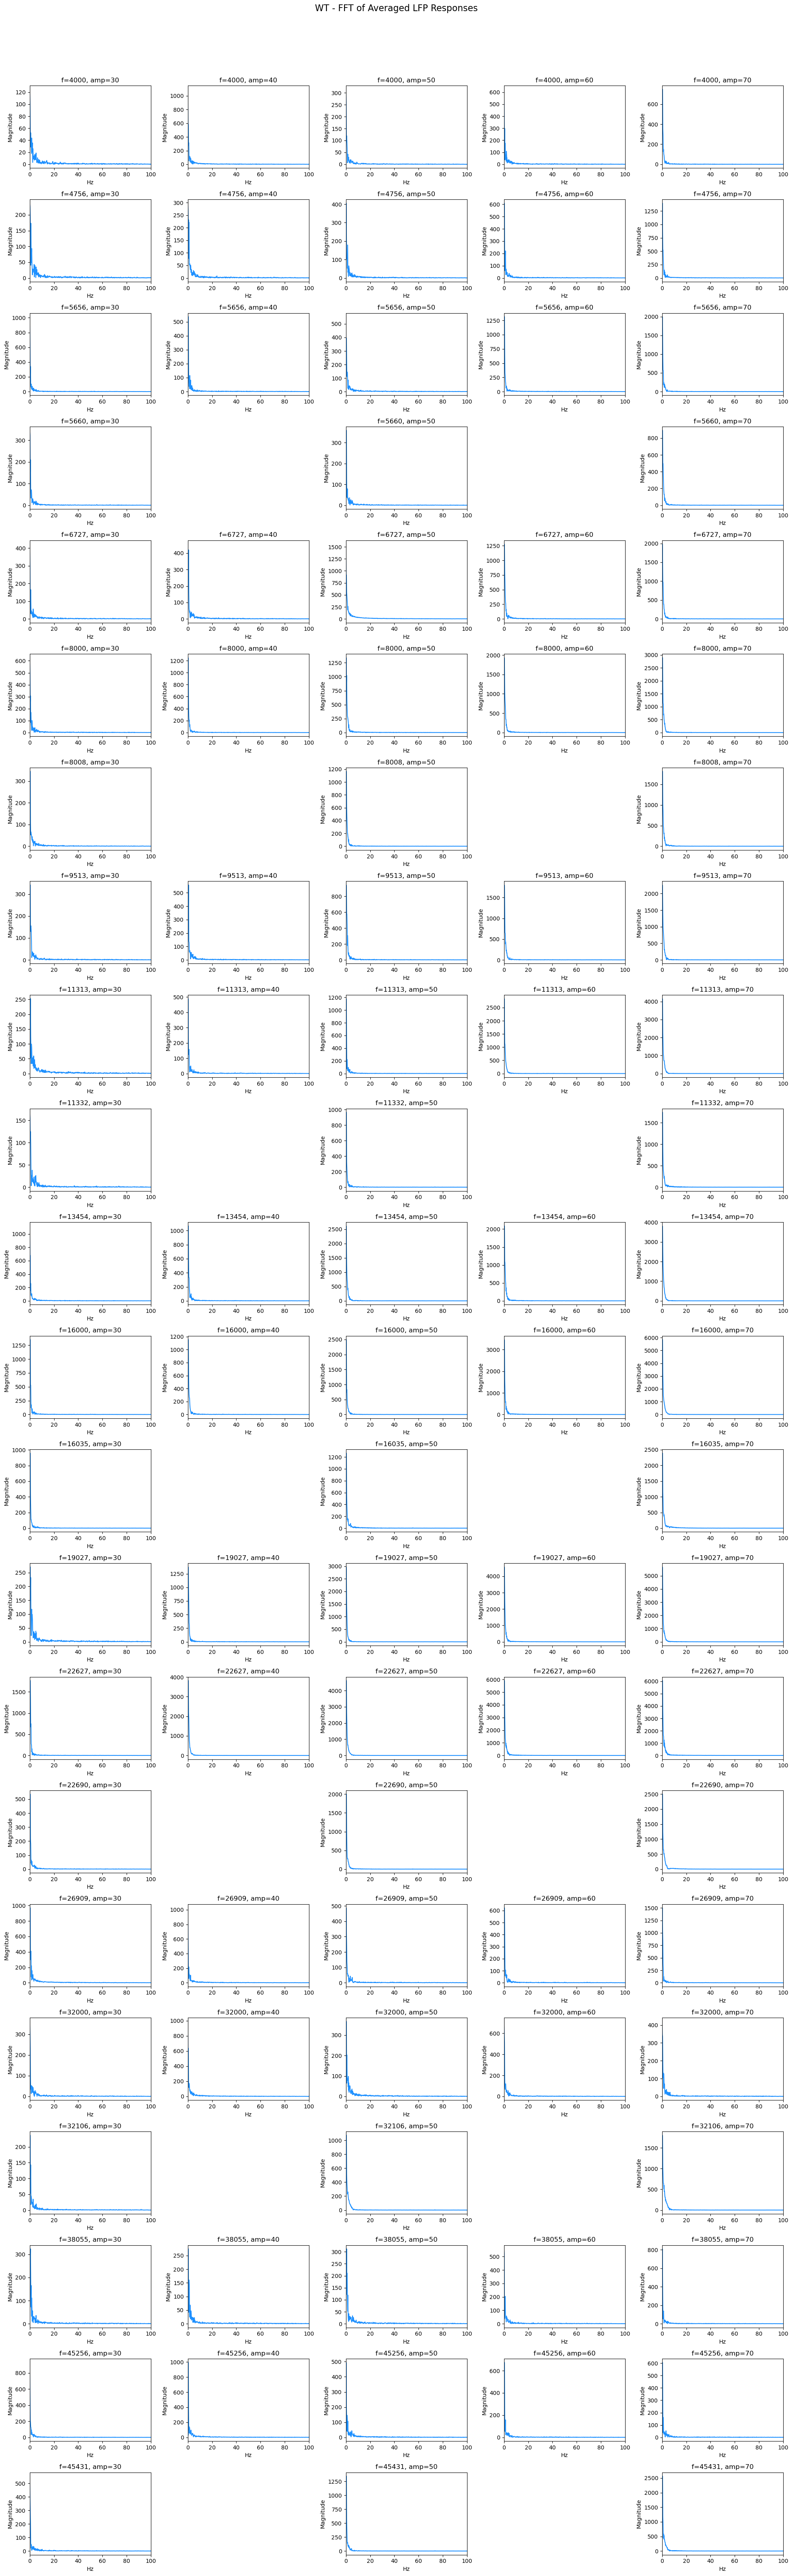


--- FMR1 ---


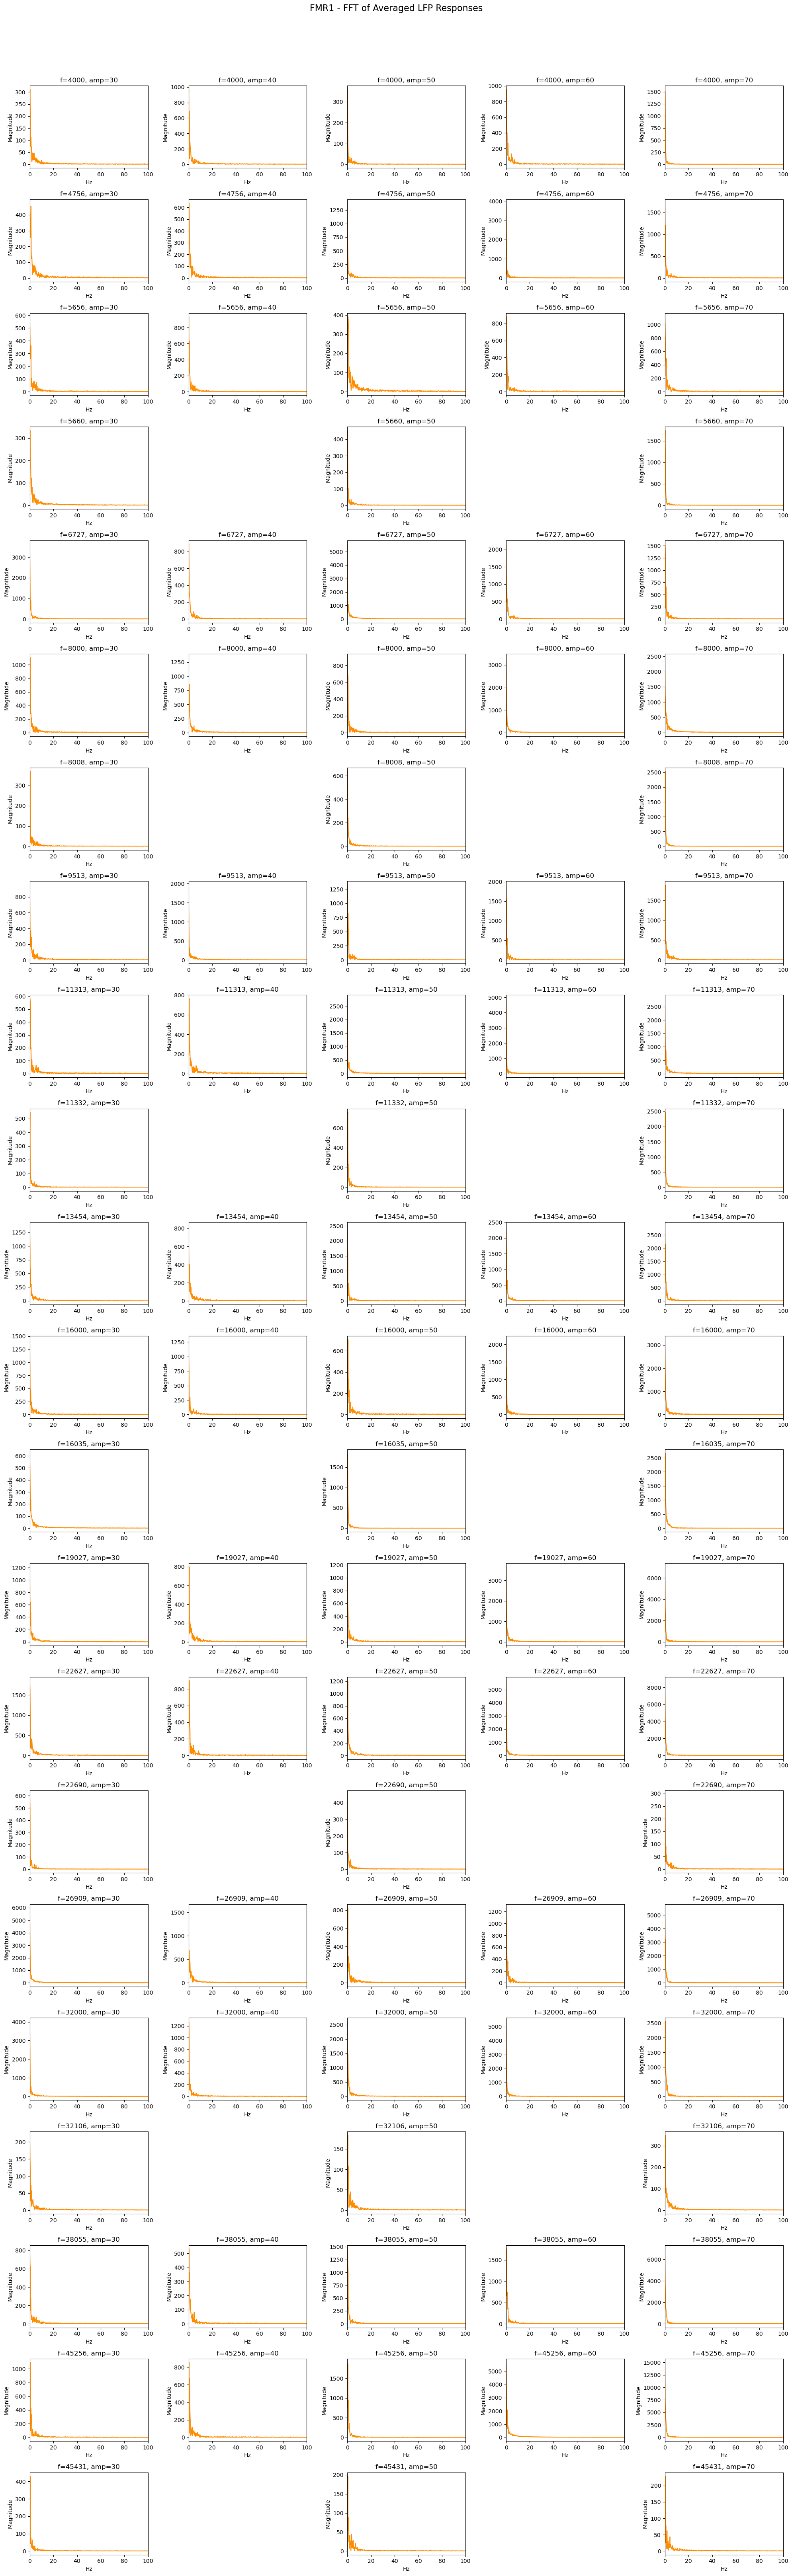

In [10]:
# Apply the FFT to auditory-evoked LFPs
# Average over each stimulus condition and stimulus group (frequency × amplitude)

# --- Basic parameters ---
fs = 1000  # Sampling frequency in Hz
t = np.linspace(0, 5, 5001)  # Time vector for 5 seconds sampled at 1000 Hz
nyquist = fs // 2  # Nyquist frequency (half the sampling rate)
freqs = fftfreq(len(t), d=1/fs)[:len(t)//2]  # Frequency bins for positive frequencies only

# --- Group setup ---
conditions = auditory_cortex["condition"].unique()  # Get unique conditions (e.g., WT, FMR1)

# Loop over each condition
for condition in conditions:
    # Filter the dataframe for the current condition
    cond_df = auditory_cortex[auditory_cortex["condition"] == condition]

    # Get sorted lists of unique stimulus frequencies and amplitudes
    freqs_list = sorted(cond_df["frequency"].unique())
    amps_list = sorted(cond_df["amplitude"].unique())

    # Determine subplot grid size
    nrows, ncols = len(freqs_list), len(amps_list)

    # Create subplot grid
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    # Print condition to console
    print(f"\n--- {condition} ---")

    # Loop over each frequency and amplitude combination
    for i, fval in enumerate(freqs_list):
        for j, aval in enumerate(amps_list):
            ax = axes[i, j]  # Select current subplot axis

            # Subset trials matching the specific frequency and amplitude
            subset = cond_df[(cond_df["frequency"] == fval) & (cond_df["amplitude"] == aval)]

            # If no trials exist for this combo, turn off subplot axis
            if subset.empty:
                ax.axis('off')
                continue

            # Stack trial traces into a 2D array: [time x trials]
            trials = np.stack(subset["trace"].values, axis=1)

            # Compute baseline from first 2 seconds (2000 samples)
            baseline = trials[:2000, :].mean(axis=0)

            # Subtract baseline from each trial
            normalized = trials - baseline

            # Average normalized LFP trace across trials
            avg = np.nanmean(normalized, axis=1)

            # --- FFT ---
            Y = fft(avg)  # Apply FFT to the averaged trace
            spectrum = np.abs(Y[:len(t)//2])  # Take magnitude of first half (positive freqs)

            # --- Plot FFT ---
            ax.plot(freqs, spectrum, color="dodgerblue" if condition == "WT" else "darkorange")  # Line color by condition
            ax.set_title(f"f={fval}, amp={aval}")  # Title includes stimulus parameters
            ax.set_xlim([0, 100])  # Limit x-axis to 0–100 Hz
            ax.set_xlabel("Hz")  # Label x-axis
            ax.set_ylabel("Magnitude")  # Label y-axis

    # Add global title to figure
    fig.suptitle(f"{condition} - FFT of Averaged LFP Responses", fontsize=16)

    # Adjust subplot layout to fit title
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Display the figure
    plt.show()



--- WT ---


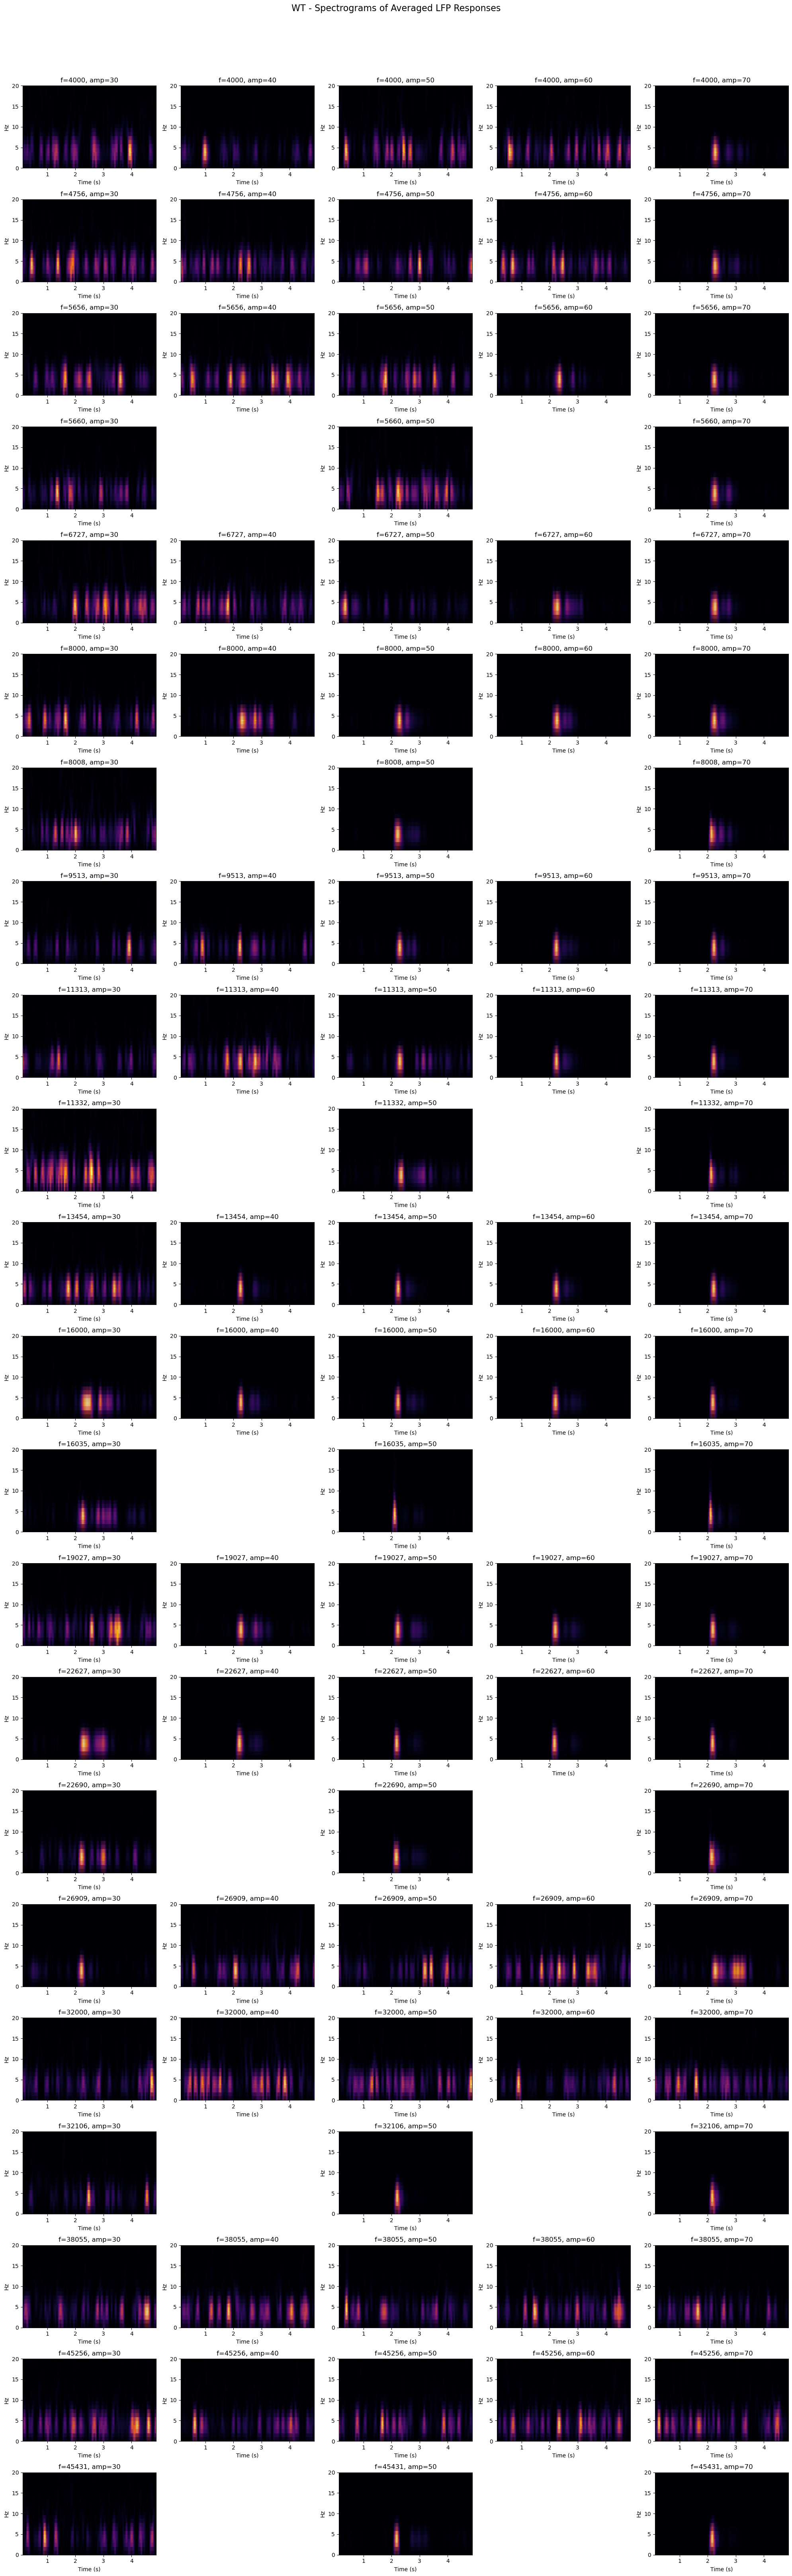


--- FMR1 ---


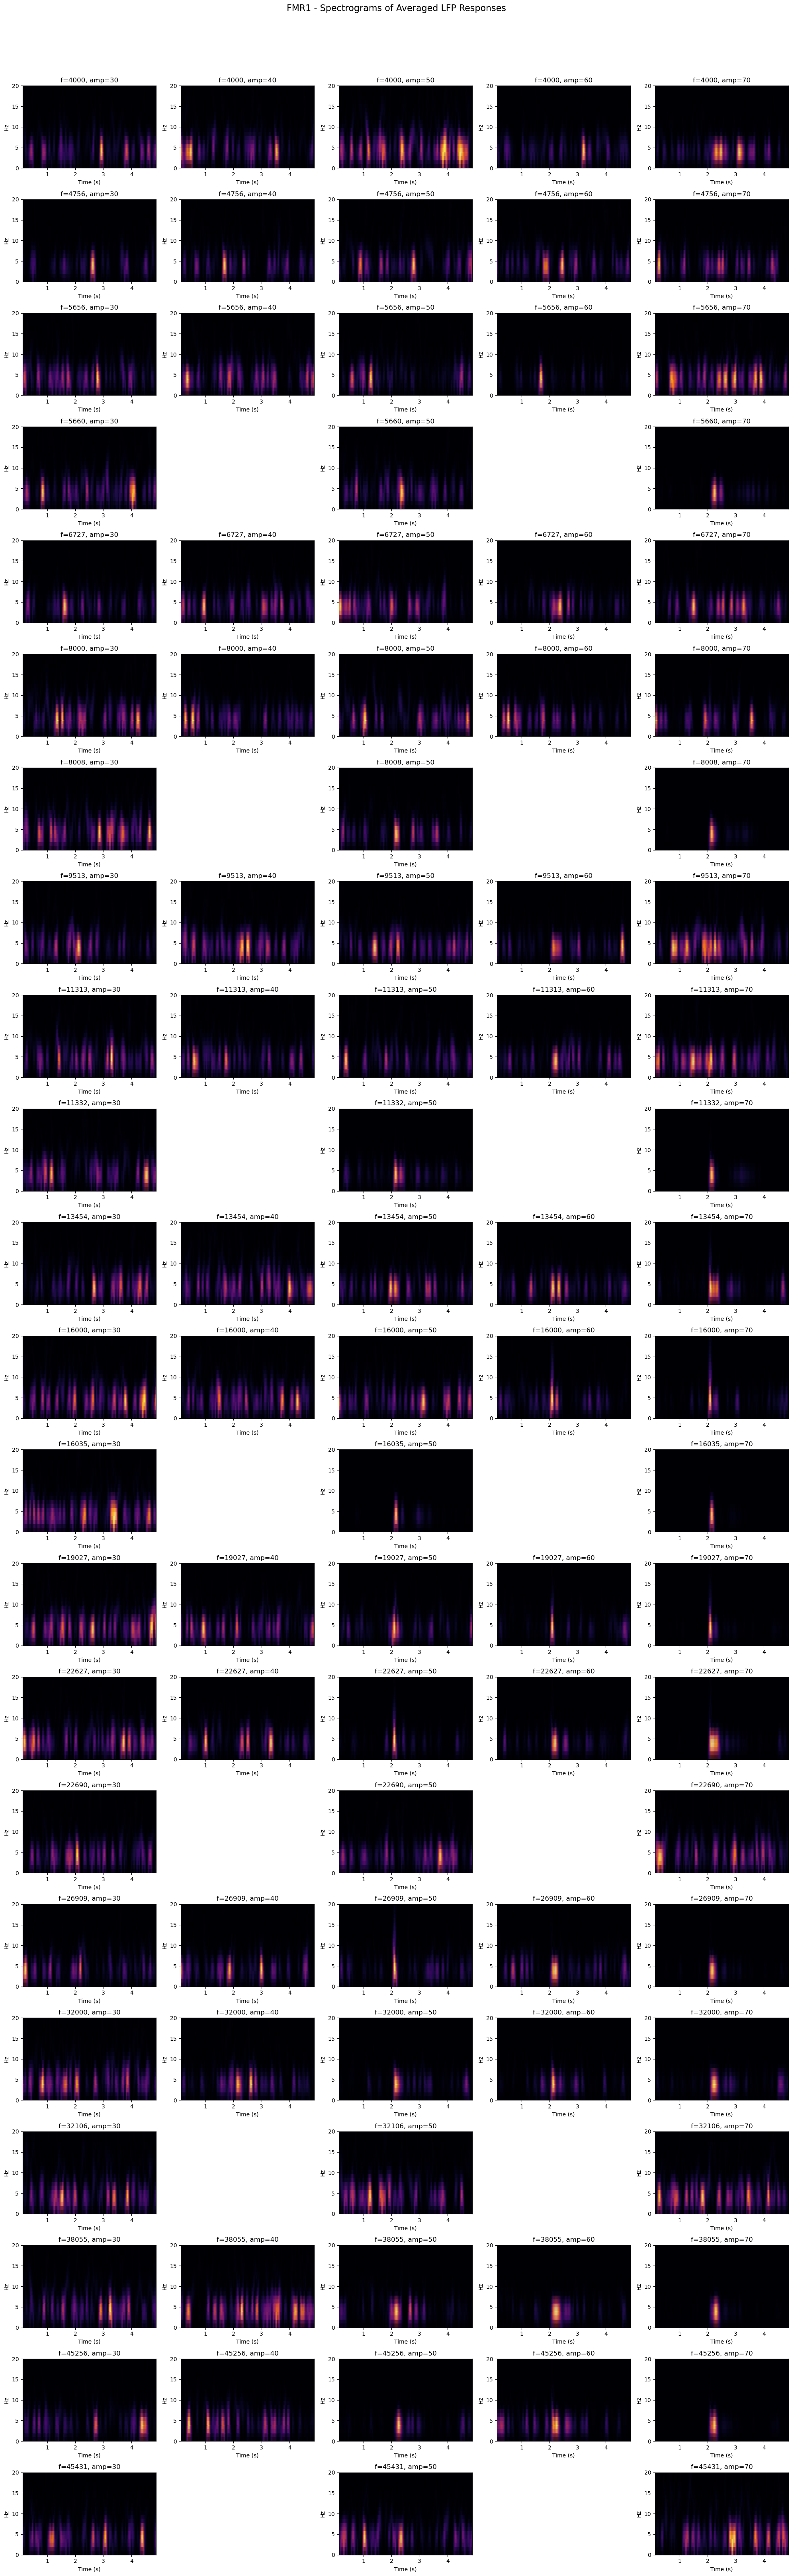

In [11]:
# Compute spectrogram from auditory-evoked LFPs
# Average trials within each stimulus condition and stimulus group (frequency × amplitude)

# --- Parameters ---
fs = 1000  # Sampling rate in Hz
t = np.linspace(0, 5, 5001)  # Time vector for 5 seconds at 1000 Hz
window = windows.hann(256)  # Hann window of length 256 for spectral smoothing; boxcar(256) or hamming(256)
noverlap = 255  # Number of overlapping samples between segments
fmax = 20  # Max frequency to display in spectrogram (Hz)

# --- Loop through conditions ---
conditions = auditory_cortex["condition"].unique()  # Get unique experimental conditions (e.g., WT, FMR1)

# Iterate through each condition (e.g., genotype)
for condition in conditions:
    cond_df = auditory_cortex[auditory_cortex["condition"] == condition]  # Filter LFP data for current condition

    # Get sorted unique stimulus frequencies and amplitudes
    freqs_list = sorted(cond_df["frequency"].unique())
    amps_list = sorted(cond_df["amplitude"].unique())

    # Set up grid layout for subplots
    nrows, ncols = len(freqs_list), len(amps_list)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    # Print condition to console
    print(f"\n--- {condition} ---")

    # Iterate through each frequency × amplitude combo
    for i, fval in enumerate(freqs_list):
        for j, aval in enumerate(amps_list):
            ax = axes[i, j]  # Select subplot axis

            # Filter trials matching this stimulus combo
            subset = cond_df[(cond_df["frequency"] == fval) & (cond_df["amplitude"] == aval)]

            # If no matching trials, turn off subplot and skip
            if subset.empty:
                ax.axis('off')
                continue

            # Stack all trial traces into a 2D array [time x trials]
            trials = np.stack(subset["trace"].values, axis=1)

            # Compute per-trial baseline (first 2 seconds = 2000 samples)
            baseline = trials[:2000, :].mean(axis=0)

            # Subtract baseline from each trial
            normalized = trials - baseline

            # Average across trials (axis=1 is trial dimension)
            avg = np.nanmean(normalized, axis=1)

            # --- Spectrogram ---
            f, tt, Sxx = spectrogram(avg, fs=fs, window=window, noverlap=noverlap, nperseg=256, nfft=512)  # Compute spectrogram
            ax.pcolormesh(tt, f, Sxx, shading='gouraud', cmap="inferno")  # Plot spectrogram as heatmap
            ax.set_ylim([0, fmax])  # Limit to lower frequencies of interest
            ax.set_title(f"f={fval}, amp={aval}")  # Title includes stimulus parameters
            ax.set_xlabel("Time (s)")  # Label x-axis
            ax.set_ylabel("Hz")  # Label y-axis

    # Add overall figure title
    fig.suptitle(f"{condition} - Spectrograms of Averaged LFP Responses", fontsize=16)

    # Adjust layout to avoid overlapping elements
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Display the figure
    plt.show()
